In [1]:
import pandas as pd

In [2]:
temp = pd.read_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/ex10/seeds_dataset.txt", 
            sep=r"\s+",
            header=None)
temp = temp.rename(columns={7:"cluster"})
temp.to_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/ex10/cleaned_ex10.csv")

In [3]:
temp

,0,1,2,3,4,5,6,cluster
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
...,...,...,...,...,...,...,...,...
205,12.19,13.20,0.8783,5.137,2.981,3.631,4.870,3
206,11.23,12.88,0.8511,5.140,2.795,4.325,5.003,3
207,13.20,13.66,0.8883,5.236,3.232,8.315,5.056,3
208,11.84,13.21,0.8521,5.175,2.836,3.598,5.044,3


In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans


X = pd.read_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/ex10/cleaned_ex10.csv").drop(columns=['cluster'])


# 1. do standarlize, cuz we r using L2 to count the distance 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# 2. build model and train, get predict

# 2.1 
kmeans_lloyd = KMeans(n_clusters=3, init='random', algorithm='lloyd', random_state=42)
labels_lloyd = kmeans_lloyd.fit_predict(X_scaled)

# 2.2
mbk = MiniBatchKMeans(
    n_clusters=3,
    init='random',
    batch_size=1,
    max_iter=100,
    random_state=42
)
labels_mq = mbk.fit_predict(X_scaled)

# 2.3
kmeans_elkan = KMeans(n_clusters=3, init='random', algorithm='elkan', random_state=42)
labels_elkan = kmeans_elkan.fit_predict(X_scaled)

# 2.4
kmeans_k_plus = KMeans(n_clusters=3, init='k-means++', algorithm='lloyd', random_state=42)
labels_k_plus = kmeans_k_plus.fit_predict(X_scaled)

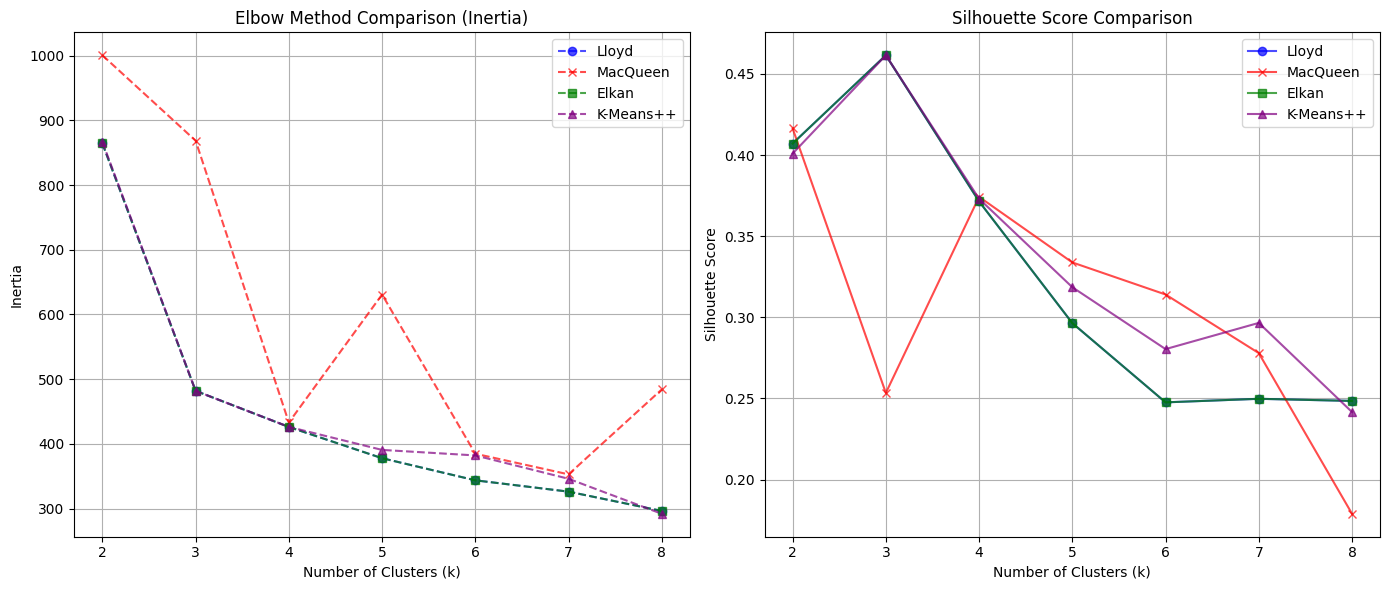

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score

# 設定 k 值測試範圍
k_range = range(2, 9)

# 建立一個字典，用來存放四種演算法的 Inertia 與 Silhouette 分數清單
results = {
    'Lloyd':      {'inertia': [], 'silhouette': [], 'color': 'blue',   'marker': 'o'},
    'MacQueen':   {'inertia': [], 'silhouette': [], 'color': 'red',    'marker': 'x'},
    'Elkan':      {'inertia': [], 'silhouette': [], 'color': 'green',  'marker': 's'},
    'K-Means++':  {'inertia': [], 'silhouette': [], 'color': 'purple', 'marker': '^'}
}

# 開始 Iteration：讓 k 跑過 2 到 8
for k in k_range:
    
    # 1. Lloyd - note that Lloyd & Elkan are ganna overlapped
    kmeans_lloyd = KMeans(n_clusters=k, init='random', algorithm='lloyd', random_state=42)
    labels_lloyd = kmeans_lloyd.fit_predict(X_scaled)
    results['Lloyd']['inertia'].append(kmeans_lloyd.inertia_)
    results['Lloyd']['silhouette'].append(silhouette_score(X_scaled, labels_lloyd))
    
    # 2. MacQueen (使用 MiniBatch 模擬)
    mbk = MiniBatchKMeans(n_clusters=k, init='random', batch_size=1, max_iter=100, random_state=42)
    labels_mq = mbk.fit_predict(X_scaled)
    results['MacQueen']['inertia'].append(mbk.inertia_)
    results['MacQueen']['silhouette'].append(silhouette_score(X_scaled, labels_mq))
    
    # 3. Elkan
    kmeans_elkan = KMeans(n_clusters=k, init='random', algorithm='elkan', random_state=42)
    labels_elkan = kmeans_elkan.fit_predict(X_scaled)
    results['Elkan']['inertia'].append(kmeans_elkan.inertia_)
    results['Elkan']['silhouette'].append(silhouette_score(X_scaled, labels_elkan))
    
    # 4. K-Means++
    kmeans_k_plus = KMeans(n_clusters=k, init='k-means++', algorithm='lloyd', random_state=42)
    labels_k_plus = kmeans_k_plus.fit_predict(X_scaled)
    results['K-Means++']['inertia'].append(kmeans_k_plus.inertia_)
    results['K-Means++']['silhouette'].append(silhouette_score(X_scaled, labels_k_plus))


# ========== 視覺化大亂鬥 ==========
plt.figure(figsize=(14, 6))

# 第一張圖：Elbow Method (Inertia)
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(k_range, data['inertia'], marker=data['marker'], color=data['color'], label=name, linestyle='--', alpha=0.7)
plt.title('Elbow Method Comparison (Inertia)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

# 第二張圖：Silhouette Score
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(k_range, data['silhouette'], marker=data['marker'], color=data['color'], label=name, linestyle='-', alpha=0.7)
plt.title('Silhouette Score Comparison')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
from sklearn.metrics import silhouette_score

labels_lloyd_score = silhouette_score(X_scaled, labels_lloyd)
labels_mq_score = silhouette_score(X_scaled, labels_mq)
labels_elkan_score = silhouette_score(X_scaled, labels_elkan)
labels_k_plus_score = silhouette_score(X_scaled, labels_k_plus)

print("silhouette_score - lloyd_score: ", labels_lloyd_score)
print("silhouette_score - mq_score:    ", labels_mq_score)
print("silhouette_score - elkan_score: ", labels_elkan_score)
print("silhouette_score - k_plus_score:", labels_k_plus_score)

silhouette_score - lloyd_score:  0.24850100658505261
silhouette_score - mq_score:     0.17894161620731286
silhouette_score - elkan_score:  0.24850100658505261
silhouette_score - k_plus_score: 0.24164379978442047


In [7]:
from sklearn.metrics import adjusted_rand_score

y_true = pd.read_csv("/Users/fangsiyu/Desktop/sdu-2026-code/804_data_mining/ex10/cleaned_ex10.csv")["cluster"]

ari_lloyd = adjusted_rand_score(y_true, labels_lloyd)
ari_mq = adjusted_rand_score(y_true, labels_mq)
ari_elkan = adjusted_rand_score(y_true, labels_elkan)
ari_k_plus = adjusted_rand_score(y_true, labels_k_plus)

print("ARI - Lloyd:      ", ari_lloyd)
print("ARI - MacQueen:   ", ari_mq)
print("ARI - Elkan:      ", ari_elkan)
print("ARI - K-Means++:  ", ari_k_plus)

ARI - Lloyd:       0.4773103874177916
ARI - MacQueen:    0.5137821309066174
ARI - Elkan:       0.4773103874177916
ARI - K-Means++:   0.4487896042197925


# ==========================================================================================
# EM Clustering
# ==========================================================================================

In [8]:
from sklearn.mixture import GaussianMixture


em_model = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
labels_em = em_model.fit_predict(X_scaled)

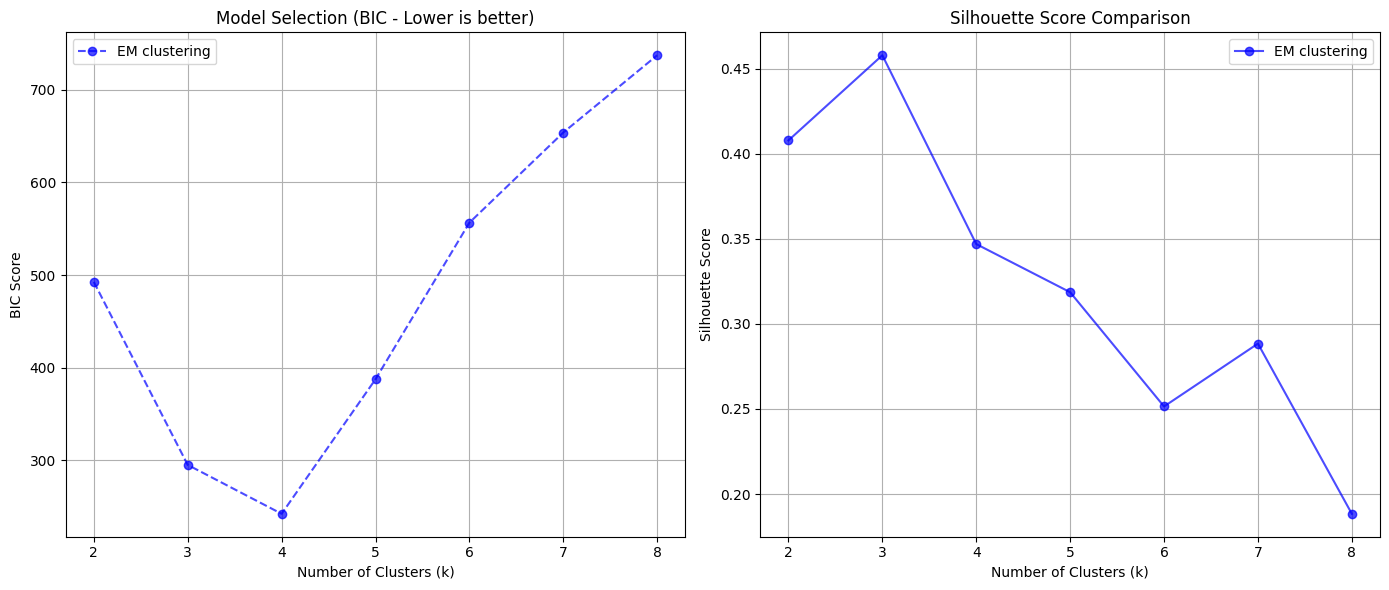

In [9]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

k_range = range(2, 9)

results = {
    'EM clustering': {'bic': [], 'silhouette': [], 'color': 'blue', 'marker': 'o'},
}

for k in k_range:
    em_model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    labels_em = em_model.fit_predict(X_scaled)

    results['EM clustering']['bic'].append(em_model.bic(X_scaled))
    results['EM clustering']['silhouette'].append(silhouette_score(X_scaled, labels_em))
    

# ========== 視覺化大亂鬥 ==========
plt.figure(figsize=(14, 6))

# 第一張圖：使用 BIC 取代 Inertia
plt.subplot(1, 2, 1)
for name, data in results.items():
    plt.plot(k_range, data['bic'], marker=data['marker'], color=data['color'], label=name, linestyle='--', alpha=0.7)
plt.title('Model Selection (BIC - Lower is better)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

# 第二張圖：Silhouette Score (維持不變)
plt.subplot(1, 2, 2)
for name, data in results.items():
    plt.plot(k_range, data['silhouette'], marker=data['marker'], color=data['color'], label=name, linestyle='-', alpha=0.7)
plt.title('Silhouette Score Comparison')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
labels_em_score = silhouette_score(X_scaled, labels_em)
ari_em = adjusted_rand_score(y_true, labels_em)

print("silhouette_score - lloyd_score:", labels_em_score)
print("ARI - EM (GMM):                ", ari_lloyd)

silhouette_score - lloyd_score: 0.18840892449036745
ARI - EM (GMM):                 0.4773103874177916


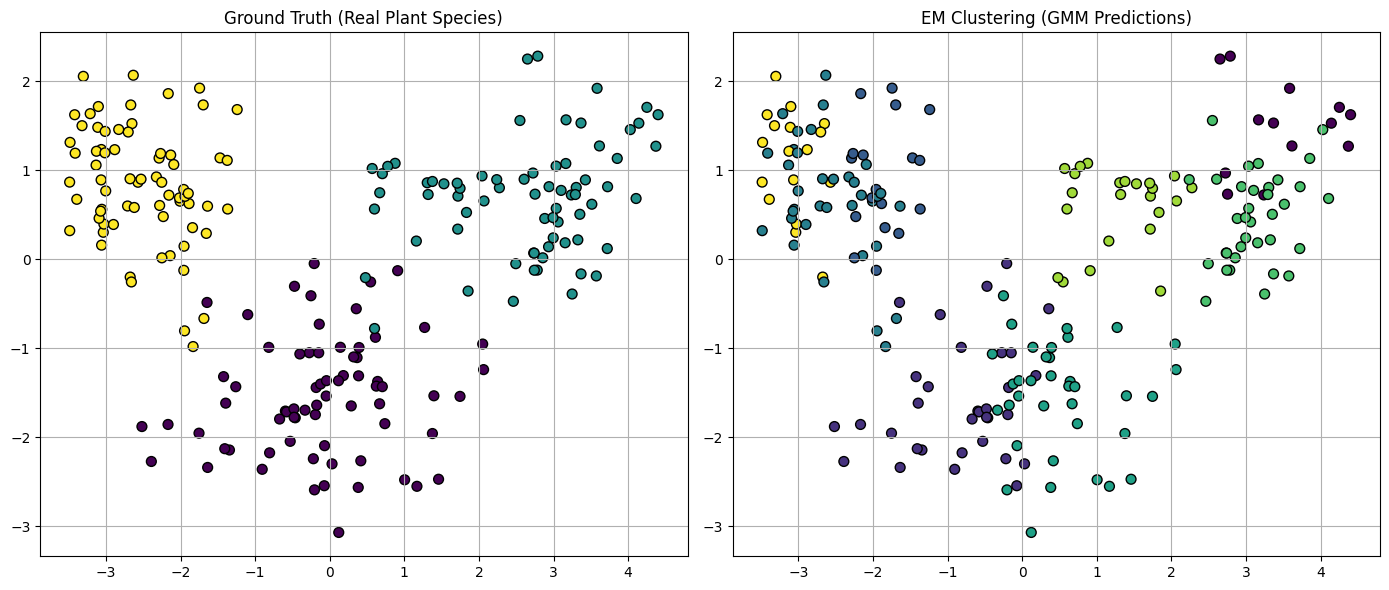

In [11]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA twist 7 dimension into 2 dimension
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter_true = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', edgecolor='k', s=50)
axes[0].set_title('Ground Truth (Real Plant Species)')
axes[0].grid(True)

scatter_em = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_em, cmap='viridis', edgecolor='k', s=50)
axes[1].set_title('EM Clustering (GMM Predictions)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [12]:
# OPT for EM Clustering

from sklearn.mixture import BayesianGaussianMixture
import numpy as np

# 1. Initialize with an intentionally high k (e.g., 10) assuming true k is unknown.
# A low 'weight_concentration_prior' forces the model to drop unnecessary clusters 
# by pushing their weights to near zero.
bgm = BayesianGaussianMixture(
    n_components=10, 
    covariance_type='full', 
    weight_concentration_prior=0.01, 
    random_state=42
)

# 2. Train the model and get predictions
labels_bgm = bgm.fit_predict(X_scaled)

# 3. Extract and display the weight of each cluster (rounded to 3 decimals)
weights = bgm.weights_
print("Weights assigned to the 10 clusters:")
print(np.round(weights, 3))

# 4. Infer the optimal k by counting clusters with weights above a threshold (e.g., 10%)
active_clusters = sum(weights > 0.1)
print(f"\nBGM inferred {active_clusters} effective clusters for this dataset.")

Weights assigned to the 10 clusters:
[0.067 0.075 0.045 0.185 0.198 0.188 0.084 0.086 0.055 0.016]

BGM inferred 3 effective clusters for this dataset.


# ==========================================================================================
# DBSCAN
# ==========================================================================================

In [16]:
import optuna
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan # Required for DBCV metric
import numpy as np
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

def objective_dbscan(trial):
    # 1. Suggest parameters for traditional DBSCAN
    eps_trial = trial.suggest_float('eps', 0.1, 2.0)
    min_samples_trial = trial.suggest_int('min_samples', 2, 15)
    
    # 2. Train model
    dbscan = DBSCAN(eps=eps_trial, min_samples=min_samples_trial)
    labels = dbscan.fit_predict(X_scaled)
    
    # 3. Guardrail: Ensure at least 2 valid clusters exist (excluding noise)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return -1.0 
        
    # 4. Target Metric: Maximize DBCV
    try:
        score = hdbscan.validity.validity_index(X_scaled, labels)
    except ValueError:
        # Failsafe for invalid cluster structures
        return -1.0
        
    return score

print("=== Starting Optuna for Traditional DBSCAN ===")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_dbscan = optuna.create_study(direction="maximize")
study_dbscan.optimize(objective_dbscan, n_trials=50)

best_eps = study_dbscan.best_params['eps']
best_min = study_dbscan.best_params['min_samples']

print(f"\n[Best Params] eps: {best_eps:.4f}, min_samples: {best_min}")

# Final evaluation with best parameters
final_dbscan = DBSCAN(eps=best_eps, min_samples=best_min)
labels_dbscan = final_dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_db = list(labels_dbscan).count(-1)

print(f"-> Valid Clusters: {n_clusters_db} | Noise Points: {n_noise_db}")
print(f"-> ARI: {adjusted_rand_score(y_true, labels_dbscan):.4f}")
print(f"-> DBCV: {hdbscan.validity.validity_index(X_scaled, labels_dbscan):.4f} (Primary Target)")
print(f"-> Silhouette: {silhouette_score(X_scaled, labels_dbscan):.4f} [Reference Only]\n")

=== Starting Optuna for Traditional DBSCAN ===

[Best Params] eps: 0.9984, min_samples: 6
-> Valid Clusters: 3 | Noise Points: 47
-> ARI: 0.6539
-> DBCV: 0.3713 (Primary Target)
-> Silhouette: 0.3416 [Reference Only]



In [17]:
import optuna
# Import HDBSCAN directly from sklearn (Requires sklearn >= 1.3.0)
from sklearn.cluster import HDBSCAN 
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan # Still required ONLY for the DBCV metric
import numpy as np
import warnings

warnings.filterwarnings("ignore")

def objective_hdbscan(trial):
    # 1. Suggest parameters for HDBSCAN
    # min_cluster_size is the primary parameter. We search between 2 and 15.
    min_cluster_size_trial = trial.suggest_int('min_cluster_size', 2, 15)
    
    # 2. Train model
    hdbscan_model = HDBSCAN(min_cluster_size=min_cluster_size_trial)
    labels = hdbscan_model.fit_predict(X_scaled)
    
    # 3. Guardrail: Ensure at least 2 valid clusters exist
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return -1.0 
        
    # 4. Target Metric: Maximize DBCV
    try:
        score = hdbscan.validity.validity_index(X_scaled, labels)
    except ValueError:
        return -1.0
        
    return score

print("=== Starting Optuna for Modern HDBSCAN ===")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_hdbscan = optuna.create_study(direction="maximize")
# We only need 20 trials here because the search space is much smaller (just one integer)
study_hdbscan.optimize(objective_hdbscan, n_trials=20)

best_min_cluster = study_hdbscan.best_params['min_cluster_size']

print(f"\n[Best Params] min_cluster_size: {best_min_cluster}")

# Final evaluation with best parameters
final_hdbscan = HDBSCAN(min_cluster_size=best_min_cluster)
labels_hdbscan = final_hdbscan.fit_predict(X_scaled)

n_clusters_hdb = len(set(labels_hdbscan)) - (1 if -1 in labels_hdbscan else 0)
n_noise_hdb = list(labels_hdbscan).count(-1)

print(f"-> Valid Clusters: {n_clusters_hdb} | Noise Points: {n_noise_hdb}")
print(f"-> ARI: {adjusted_rand_score(y_true, labels_hdbscan):.4f}")
print(f"-> DBCV: {hdbscan.validity.validity_index(X_scaled, labels_hdbscan):.4f} (Primary Target)")
# Try-except block for Silhouette because HDBSCAN might classify EVERYTHING as noise (-1) in edge cases
try:
    sil_score = silhouette_score(X_scaled, labels_hdbscan)
    print(f"-> Silhouette: {sil_score:.4f} [Reference Only]\n")
except ValueError:
    print("-> Silhouette: N/A (Only 1 cluster or all noise)\n")

=== Starting Optuna for Modern HDBSCAN ===

[Best Params] min_cluster_size: 7
-> Valid Clusters: 3 | Noise Points: 52
-> ARI: 0.6231
-> DBCV: 0.3415 (Primary Target)
-> Silhouette: 0.3132 [Reference Only]



# ==========================================================================================
# SNN clustering
# ==========================================================================================

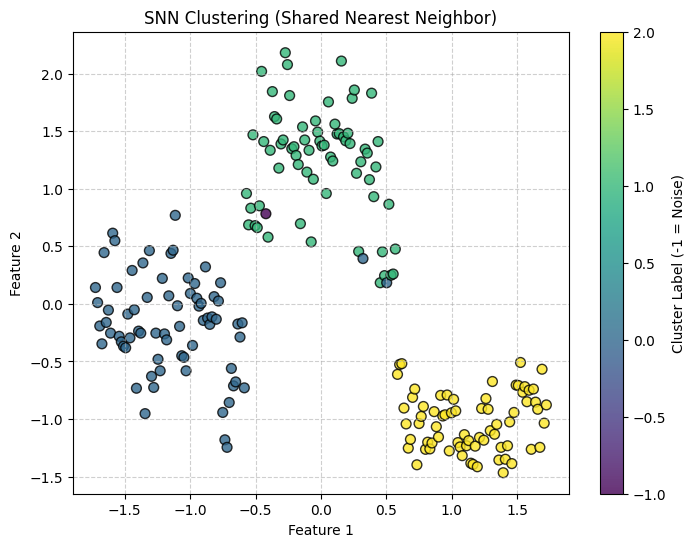

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# 1. 產生測試資料：雙半月形 (這種形狀最能展現密度/SNN分群的威力)
# X, _ = make_moons(n_samples=300, noise=0.08, random_state=42)

# ========== SNN 演算法核心開始 ==========

# 步驟 A：找出每個點的 k 個好朋友 (KNN)
k = 15
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_scaled)
# 取得 KNN 的連接矩陣 (有連線就是 1，沒連線就是 0)
graph = nn.kneighbors_graph(X_scaled, mode='connectivity')

# 步驟 B：計算 SNN 相似度矩陣 (兩點之間共享了幾個朋友？)
# 矩陣乘上自己的轉置，剛好就是交集的數量！(這是極度優雅的線性代數解法)
snn_similarity = graph.dot(graph.T).toarray()

# 步驟 C：將「相似度」翻轉成「距離」
# DBSCAN 需要的是距離 (數字越小代表越親密)。
# 最大共享數是 k，所以「k - 共享數量」就是距離。共享越多，距離越趨近於 0。
snn_distance = k - snn_similarity

# 步驟 D：將 SNN 距離矩陣丟給 DBSCAN 進行分群
# metric='precomputed' 代表告訴 DBSCAN：不要自己算距離了，吃我算好的 SNN 距離矩陣！
# eps=7 代表：只要我們的 SNN 距離小於 7 (也就是至少共享 15-7=8 個朋友)，就算同一群
dbscan_snn = DBSCAN(eps=7, min_samples=6, metric='precomputed')
labels = dbscan_snn.fit_predict(snn_distance)

# ========== 視覺化繪圖 ==========
plt.figure(figsize=(8, 6))

# 使用 scatter 畫出分群結果，標籤為 -1 的點會自動被視為雜訊 (Noise)
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k', alpha=0.8)

plt.title("SNN Clustering (Shared Nearest Neighbor)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(scatter, label="Cluster Label (-1 = Noise)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [22]:
import optuna
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
import hdbscan # Required for DBCV
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# 1. Define Optuna Objective Function for SNN
def objective_snn(trial):
    # Suggest 'k' (number of neighbors to consider for the social network)
    k_trial = trial.suggest_int('k', 5, 30)
    
    # Suggest 'eps'. In SNN, max distance is 'k'. So eps must be an integer between 1 and k.
    eps_trial = trial.suggest_int('eps', 1, k_trial)
    
    # Suggest 'min_samples' for the DBSCAN engine
    min_samples_trial = trial.suggest_int('min_samples', 2, 15)
    
    # --- SNN Distance Calculation ---
    nn = NearestNeighbors(n_neighbors=k_trial)
    nn.fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
    
    snn_similarity = graph.dot(graph.T).toarray()
    snn_distance = k_trial - snn_similarity
    
    # --- Run DBSCAN Engine ---
    dbscan_snn = DBSCAN(eps=eps_trial, min_samples=min_samples_trial, metric='precomputed')
    labels = dbscan_snn.fit_predict(snn_distance)
    
    # Guardrail: Check if valid clusters exist
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return -1.0
        
    # Target Metric: Maximize DBCV
    try:
        score = hdbscan.validity.validity_index(X_scaled, labels)
    except ValueError:
        return -1.0
        
    return score

# 2. Start Optuna Study
print("=== Starting Optuna for SNN Clustering ===")
optuna.logging.set_verbosity(optuna.logging.WARNING) 
study_snn = optuna.create_study(direction="maximize")
study_snn.optimize(objective_snn, n_trials=50)

# 3. Extract Best Parameters
best_k = study_snn.best_params['k']
best_eps = study_snn.best_params['eps']
best_min = study_snn.best_params['min_samples']

print(f"[Best Params] k: {best_k}, eps: {best_eps}, min_samples: {best_min}")

# 4. Final Evaluation with Best Parameters
# Re-calculate SNN distance with the best 'k'
nn_best = NearestNeighbors(n_neighbors=best_k)
nn_best.fit(X_scaled)
graph_best = nn_best.kneighbors_graph(X_scaled, mode='connectivity')
snn_distance_best = best_k - graph_best.dot(graph_best.T).toarray()

# Run DBSCAN with best 'eps' and 'min_samples'
final_snn = DBSCAN(eps=best_eps, min_samples=best_min, metric='precomputed')
labels_snn = final_snn.fit_predict(snn_distance_best)

# Calculate final metrics
n_clusters_snn = len(set(labels_snn)) - (1 if -1 in labels_snn else 0)
n_noise_snn = list(labels_snn).count(-1)
ari_snn = adjusted_rand_score(y_true, labels_snn)
dbcv_snn = hdbscan.validity.validity_index(X_scaled, labels_snn)

# Silhouette requires coordinate data (X_scaled), not the precomputed distance
try:
    sil_snn = silhouette_score(X_scaled, labels_snn)
except ValueError:
    sil_snn = -1.0 # Failsafe if only noise is left

# 5. Output in requested format
print(f"-> Valid Clusters: {n_clusters_snn} | Noise Points: {n_noise_snn}")
print(f"-> ARI: {ari_snn:.4f}")
print(f"-> DBCV: {dbcv_snn:.4f} (Primary Target)")
if sil_snn != -1.0:
    print(f"-> Silhouette: {sil_snn:.4f} [Reference Only]")
else:
    print("-> Silhouette: N/A [Reference Only]")

=== Starting Optuna for SNN Clustering ===
[Best Params] k: 18, eps: 11, min_samples: 14
-> Valid Clusters: 2 | Noise Points: 0
-> ARI: 0.5691
-> DBCV: 0.2660 (Primary Target)
-> Silhouette: 0.4087 [Reference Only]


In [24]:
import optuna
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score
import hdbscan # 引入 hdbscan 來計算 DBCV

# 1. 核心任務：Optuna 每次嘗試都會跑這裡
def objective(trial):
    # 抽參數
    k = trial.suggest_int('k', 5, 30)
    eps = trial.suggest_int('eps', 1, k)
    
    # SNN：計算共同好友的「距離表」
    nn = NearestNeighbors(n_neighbors=k).fit(X_scaled)
    graph = nn.kneighbors_graph(X_scaled, mode='connectivity')
    snn_distance = k - graph.dot(graph.T).toarray()
    
    # DBSCAN：吃 SNN 的距離表來貼標籤
    dbscan = DBSCAN(eps=eps, min_samples=5, metric='precomputed')
    labels = dbscan.fit_predict(snn_distance)
    
    # 防呆與評分 (如果全部分成同一群就給最低分 -1)
    if len(set(labels)) < 2: 
        return -1.0
        
    # 回傳 ARI 分數讓 Optuna 去努力衝高 (我們依然用上帝視角找最佳解)
    return adjusted_rand_score(y_true, labels)

# 2. 啟動優化 (關閉囉嗦的 log，只跑 30 次)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

# ================= 新增：最終成績單檢測 =================

# 3. 取得最強參數
best_k = study.best_params['k']
best_eps = study.best_params['eps']

# 使用最強參數，手動重跑一次 SNN 與 DBSCAN
nn_best = NearestNeighbors(n_neighbors=best_k).fit(X_scaled)
graph_best = nn_best.kneighbors_graph(X_scaled, mode='connectivity')
snn_distance_best = best_k - graph_best.dot(graph_best.T).toarray()

best_dbscan = DBSCAN(eps=best_eps, min_samples=5, metric='precomputed')
best_labels = best_dbscan.fit_predict(snn_distance_best)

# 4. 計算 DBCV 
# (加上 try-except 防呆，以免最佳參數剛好切出 DBCV 無法計算的形狀)
try:
    dbcv_score = hdbscan.validity.validity_index(X_scaled, best_labels)
except ValueError:
    dbcv_score = -1.0

# 5. 直接看結果
print("\n========== 最終優化結果 ==========")
print(f"找到的最強參數: {study.best_params}")
print(f"達到的最高 ARI 分數: {study.best_value:.4f} (Optuna 的優化目標)")
print(f"這組完美參數的 DBCV: {dbcv_score:.4f} [對照參考]")
print("==================================\n")


========== 最終優化結果 ==========
找到的最強參數: {'k': 19, 'eps': 9}
達到的最高 ARI 分數: 0.9646 (Optuna 的優化目標)
這組完美參數的 DBCV: 0.1184 [對照參考]

